# Deep clustering of rain-induced noise: training part

This notebook implements the method of using Deep Embedded Clustering (DEC) to characterize different rain-induced noise recorded by FORESEE DAS array and presents the training process to get well-trained DEC model. 

The notebook takes spectrograms of DAS recordings as input and outputs the labels. The preprocess from DAS raw waveforms to the spectograms is not included in this notebook.

Details about rain-induced DAS noise can be found in Section 3 and Section 5 in *Shen, J. & Zhu, T. (2023). DAS with telecommunication fiber-optic cable in urban areas can record storm-induced seismic noise, Geophysical Journal International. 235(3), 2122–2136. https://doi.org/10.1093/gji/ggad352"*

**Content:** 
1. Prepare data 
2. Training stage 1: Pretrain Autoencoder
3. Training stage 2: Train DEC
4. Checking training results

**Figures:**

This notebook is used to plot Figures 3, 4, 5, 6 and 10 in the manuscript.

In [1]:
import os

import numpy as np
import pandas as pd
from scipy import ndimage

import torch
from torch import nn, optim

from model_DEC import autoencoder, DEC_net
from DEC_utils import get_stft_freq, switch_label, fft_taper
import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)

2.3.1+cu121


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [4]:
import config as args
np.random.seed(0)
workdir = '/egg1/s2/jxs2475/codes/AE/DEC_DAS'
device = 'cuda' if torch.cuda.is_available() else print('Error! cuda not available!')
# device = 'cpu'

In [5]:
from matplotlib.ticker import MultipleLocator,LogLocator,MaxNLocator
font = {'size': 11}
plt.rc('font', **font)

# 0. Network summary

In [6]:
from torchsummary import summary
net = DEC_net(args).cuda()
summary(net, input_size=(1, 76, 56))

Layer (type:depth-idx)                        Param #
├─autoencoder: 1-1                            --
|    └─CNN_Encoder: 2-1                       --
|    |    └─Sequential: 3-1                   50,244
|    └─CNN_Decoder: 2-2                       --
|    |    └─Sequential: 3-2                   26,880
|    |    └─Sequential: 3-3                   24,433
├─clustering: 1-2                             80
Total params: 101,637
Trainable params: 101,637
Non-trainable params: 0


Layer (type:depth-idx)                        Param #
├─autoencoder: 1-1                            --
|    └─CNN_Encoder: 2-1                       --
|    |    └─Sequential: 3-1                   50,244
|    └─CNN_Decoder: 2-2                       --
|    |    └─Sequential: 3-2                   26,880
|    |    └─Sequential: 3-3                   24,433
├─clustering: 1-2                             80
Total params: 101,637
Trainable params: 101,637
Non-trainable params: 0

# 1. Prepare data

## 1.1 Load precipitation data

We use precipitation data to guide data selection for training. 

In [7]:
# Preprocess precipitation data (Resample and interpolate)
df = pd.read_csv('/egg1/s2/jxs2475/rain_beaver.csv',parse_dates=True,index_col=[1])
df = df.resample('T').mean()
df.index = df.index + pd.DateOffset(hours=4)
df['Rain Rate'] = df['Rain Rate'].interpolate()

df_sub = df[df.index.isin(pd.date_range(start='2021-06-01 00:00',
                                    end='2021-08-16 00:00',freq='T'))]
rain = df_sub['Rain Rate'].values

# Generate label based on the rain (0: no rain, >=1: rain)
rain_label = np.zeros_like(rain)
for i in range(rain.size):
    if (rain[i]>=0.01)&(rain[i]<1.5):
        rain_label[i]=1
    elif rain[i]>=1.5:
        rain_label[i]=2

In [8]:
# Select all the rain signals. 
index_yes = np.nonzero(rain_label)[0]

# Randomly select noise data from label 0. The size of noise data is 40% of the size of rain signals
random_index = np.random.choice(np.where(rain_label==0)[0].size, int(0.4*index_yes.size))
index_no = np.where(rain_label==0)[0][random_index]

# Index for training examples in continous recordings.
new_index = np.append(index_no, index_yes)

print("Rain signals: {}, Noise: {}".format(index_yes.size, index_no.size))
rain_train = rain[new_index]

Rain signals: 3227, Noise: 1290


## 1.2. Load and preprocess training dataset

In [9]:
def preprocess_input(data):
    # standarize data
    data = np.log(data)
    nsamples = data.shape[0]

    X = np.reshape(data, (nsamples, 76*56))
    scaler = StandardScaler()
    # scaler = MinMaxScaler(feature_range=(-1, 1))
    X = scaler.fit_transform(X.T).T
    X = np.reshape(X, (nsamples, 76, 56))
    data0 = X
    return data0

In [10]:
# Load spectrums and form the training dataset
data1 = np.load(workdir+'/data/DAS_spec/spec_359_jun21.npy')
data2 = np.load(workdir+'/data/DAS_spec/spec_359_jul21_aug21.npy')
data = np.concatenate((data1, data2), axis=0)
print("Total DAS data: ",  data.shape)
data_train_raw = data[new_index]
    
data_train = preprocess_input(data_train_raw)
print("Training DAS data: ",  data_train.shape)

Total DAS data:  (132480, 76, 56)
Training DAS data:  (4517, 76, 56)


## 1.3. Split train and validation

In [11]:
split_index = np.arange(0, data_train.shape[0])
train_size = 0.9
d_train, d_val, index_train, _ = train_test_split(data_train, split_index, test_size=1-train_size, random_state=0)

In [12]:
d_train = torch.from_numpy(d_train).to(device).to(torch.float32) 
d_val = torch.from_numpy(d_val).to(device).to(torch.float32)  

batch_size = args.batch_size
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(d_train),
    batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(d_val),
    batch_size=batch_size, shuffle=True, drop_last=True)

# 2. Stage 1: Pretrain autoencoder

## 2.1 Train

In [18]:
def pretrain(epoch):
    """Pretrain Autoencoder"""
    # train
    AE.train()
    optimizer = optim.Adam(AE.parameters(), lr=1e-3)
    loss_function = nn.MSELoss()
    train_loss = 0
    for batch_idx, (data,) in enumerate(train_loader):
        optimizer.zero_grad()
        recon_batch, _ = AE(data)
        recon_batch = torch.reshape(recon_batch, (-1,76,56))
        loss = loss_function(recon_batch, data)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    # evaluation
    AE.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_idx, (data,) in enumerate(val_loader):
            recon_batch, _ = AE(data)
            recon_batch = torch.reshape(recon_batch, (-1,76,56))
            loss = loss_function(recon_batch, data)
            val_loss += loss.item()
    
    print('====> Epoch: {} Training loss: {:.4f}, validation loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset), val_loss/len(val_loader.dataset)))
    
    return train_loss / len(train_loader.dataset), val_loss/len(val_loader.dataset)

In [19]:
AE = autoencoder(args).cuda()
loss1 = []
loss2 = []
for epoch in range(40):
    l1, l2 = pretrain(epoch)
    loss1.append(l1)
    loss2.append(l2)

====> Epoch: 0 Training loss: 0.0124, validation loss: 0.0091
====> Epoch: 1 Training loss: 0.0076, validation loss: 0.0068
====> Epoch: 2 Training loss: 0.0066, validation loss: 0.0064
====> Epoch: 3 Training loss: 0.0064, validation loss: 0.0063
====> Epoch: 4 Training loss: 0.0063, validation loss: 0.0062
====> Epoch: 5 Training loss: 0.0062, validation loss: 0.0061
====> Epoch: 6 Training loss: 0.0062, validation loss: 0.0061
====> Epoch: 7 Training loss: 0.0061, validation loss: 0.0061
====> Epoch: 8 Training loss: 0.0061, validation loss: 0.0060
====> Epoch: 9 Training loss: 0.0061, validation loss: 0.0060
====> Epoch: 10 Training loss: 0.0061, validation loss: 0.0060
====> Epoch: 11 Training loss: 0.0060, validation loss: 0.0060
====> Epoch: 12 Training loss: 0.0060, validation loss: 0.0060
====> Epoch: 13 Training loss: 0.0060, validation loss: 0.0060
====> Epoch: 14 Training loss: 0.0060, validation loss: 0.0059
====> Epoch: 15 Training loss: 0.0059, validation loss: 0.0059
==

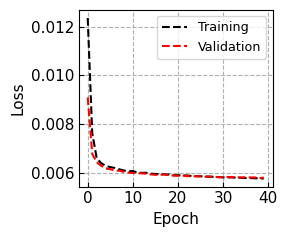

In [20]:
# plot convergence curve
fig, ax = plt.subplots(figsize=(3,2.5))
ax.plot(loss1, label='Training', c='k', ls='--')
ax.plot(loss2, label='Validation', c='r', ls='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
# ax.tick_params(axis='x', labelsize=11)
# ax.tick_params(axis='y', labelsize=11)
ax.yaxis.set_major_locator(MultipleLocator(0.002))
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.legend(fontsize='small')
ax.grid(ls='--')
ax.tick_params(axis='both', direction='in')

plt.tight_layout()

## 2.2. Evaluate the reconstruction performance

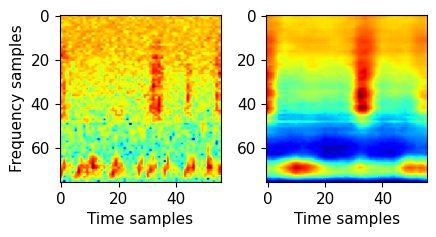

In [21]:
isample = 4300
d_eval = torch.from_numpy(data_train[isample]).to(device).to(torch.float32)

x, z = AE(d_eval)
recon_img = x.detach().cpu().numpy()
recon_img = np.reshape(recon_img, (76,56))

fig, axs =plt.subplots(ncols=2, figsize=(4.5,2.5))
axs[0].imshow(data_train[isample], aspect='auto', cmap='jet')
axs[0].set(xlabel='Time samples', ylabel='Frequency samples')

axs[1].imshow(recon_img, aspect='auto', cmap='jet')
axs[1].set(xlabel='Time samples')
plt.tight_layout()
# plt.savefig('./figure/paper/Fig4_2b', dpi=300)

## 2.3 Save the model

In [23]:
# save weights
torch.save(AE.state_dict(), workdir+'/results/model_weights/pretrained_AE_v4') # Tune in Sept 2023
# save losses
save_dir = workdir+'/results/DEC_logs/v4/'
np.save(save_dir+'pretrain_training_loss1.npy', loss1)
np.save(save_dir+'pretrain_training_loss2.npy', loss2)

# 3. Stage 2: Train DEC

## 3.1. Initialize the DEC

In [13]:
# include all training data
torch.manual_seed(0)
idx = torch.randperm(d_train.shape[0])
d_train_shuffle = d_train[idx].view(d_train.size())

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(d_train_shuffle),
    batch_size=batch_size, shuffle=False, drop_last=True)

In [14]:
# Define DEC with pretrained autoencoder 
DEC = DEC_net(args).cuda()
DEC.AE.load_state_dict(torch.load(workdir+'/results/model_weights/pretrained_AE_v4', map_location=args.device))

<All keys matched successfully>

In [15]:
# Initializing the cluster centers
DEC.train()

X = d_train[:len(train_loader)*batch_size]

with torch.no_grad():
    kmeans = KMeans(n_clusters=args.n_clusters, n_init=20, random_state=0)
    
    labels_prev = kmeans.fit_predict(DEC.AE.encode(X).clone().detach().cpu())

    clustcenters = torch.tensor(kmeans.cluster_centers_, dtype=torch.float, requires_grad=True)
    clustcenters = clustcenters.to(device)

    DEC.state_dict()["clusterlayer.clustcenters"].copy_(clustcenters)

# Save the initial DEC model for comparison
DEC_init = DEC_net(args).cuda()
DEC_init.load_state_dict(DEC.state_dict())

<All keys matched successfully>

## 3.2 Elbow method to determine the number of clusters

In [38]:
X = d_train[:len(train_loader)*batch_size]
X_kmeans = DEC.AE.encode(X).clone().detach().cpu()

wcss = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_kmeans)  # X is your data
    wcss.append(kmeans.inertia_)

## 3.3. t-SNE visualization of latent space before DEC 

In [28]:
def plot_tsne():
    """Function for plotting distribution"""
    fig, ax = plt.subplots(figsize=(5,5))
    for i in range(args.n_clusters):
        class_idx = np.where(label==i)[0]
        ax.scatter(tsne_results[class_idx,0], tsne_results[class_idx,1], s=10, alpha=0.7, edgecolors='black', linewidths=0.5)

    ax.scatter(tsne_results[-center.shape[0]:,0], tsne_results[-center.shape[0]:,1], s=200, c='y' ,marker='*', edgecolors='black', linewidths=0.5)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.tight_layout()
    plt.show()

In [29]:
# get latent vectors z and corresponding label
q, x, z = DEC_init(d_train)
z = z.cpu().detach().numpy()
q = q.cpu().detach().numpy()
label = np.argmax(q, axis=1)
# get centroid
center = DEC_init.clusterlayer.clustcenters.cpu().detach().numpy()
z = np.append(z, center, axis=0)

In [30]:
tsne = TSNE(random_state=0)
tsne_results = tsne.fit_transform(z)

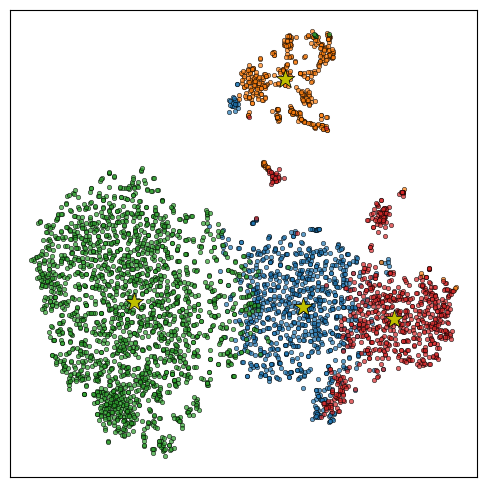

In [31]:
plot_tsne()
# plt.savefig('./figure/paper/Fig4_4a', dpi=300)

## 3.4. DEC training

In [32]:
update_interval = args.update_interval

In [33]:
def batch_eval(dataloader, model, device, mute=True):
    """ Calculate sample distribution across the whole training dataset. """
    model.eval()
    bsz = train_loader.batch_size
    
    q_array = np.zeros(
        (len(dataloader)*bsz,
        model.n_clusters),
        dtype=np.float32
    )
    for b, (batch,) in enumerate(dataloader):
        x = batch.to(device)
        q, _, z = model(x)
        q_array[b*bsz:(b*bsz)+x.size(0), :] = q.detach().cpu().numpy()
        
    labels = np.argmax(q_array.data, axis=1)
    q_array = torch.from_numpy(q_array).to(device)
    return q_array, labels

In [34]:
def DEC_train(epoch, labels_prev):
    
    global target, q, labels
    
    loss_function = nn.KLDivLoss(reduction='batchmean')
    loss_MSE = nn.MSELoss()
    optimizer = torch.optim.SGD(DEC.parameters(), lr = 1e-2, momentum=0.9)

    DEC.train()
    loss_total = 0
    loss_kl = 0
    loss_ae = 0
    running_size = 0 
    

    # Before DEC training, check if need update target distribution after "update_interval" epoch
    if (epoch % update_interval == 0):
        q, labels = batch_eval(train_loader, DEC, 'cuda')
        target = DEC.clusterlayer.target_distribution(q)
        
        delta_label = np.sum(labels != labels_prev).astype(np.float32)/labels.shape[0]
        labels_prev = np.copy(labels)
    
    # update DEC parameter
    for batch_idx, (data,) in enumerate(train_loader):
        # target distribution for this batch    
        target_dist = target[running_size:(running_size + data.size(0)), :]
        
        DEC.train()
        q, x, z = DEC(data)
        
        loss1 = 0.2*loss_function(q.log(), target_dist)
        x = torch.reshape(x, (-1,76,56))
        loss2 = loss_MSE(x, data)
        loss = loss1 + loss2
        optimizer.zero_grad()
        loss.backward()
        optimizer.step(closure=None)
        
        running_size += data.size(0)
        
        loss_total += loss.item()
        loss_kl += loss1.item()
        loss_ae += loss2.item()
    
    # logging
    log_loss = np.array([loss_total, loss_kl, loss_ae])*1000/len(train_loader.dataset)
    log_label = labels
    
    # print history
    if epoch%10==0:
        print('====> Epoch: {} Training loss: {:.4f}'.format(
          epoch, log_loss[0]))

    return log_loss, log_label

In [35]:
# train the DEC
log_loss = []
log_label = []
for epoch in range(100):
    log1, log2 = DEC_train(epoch, labels_prev)
    log_loss.append(log1)
    log_label.append(log2)
    
log_loss = np.vstack(log_loss)
log_label = np.vstack(log_label)

====> Epoch: 0 Training loss: 6.0584
====> Epoch: 10 Training loss: 6.1323
====> Epoch: 20 Training loss: 6.1267
====> Epoch: 30 Training loss: 6.1109
====> Epoch: 40 Training loss: 6.0952
====> Epoch: 50 Training loss: 6.0810
====> Epoch: 60 Training loss: 6.0679
====> Epoch: 70 Training loss: 6.0560
====> Epoch: 80 Training loss: 6.0451
====> Epoch: 90 Training loss: 6.0352


In [13]:
# !!!!!
# save_dir = workdir+'/results/DEC_logs/v4/'
# if not os.path.exists(save_dir):
#     os.makedirs(save_dir)
# np.save(save_dir+'log_loss.npy', log_loss)
# np.save(save_dir+'log_label.npy', log_label)
# torch.save(DEC.state_dict(), workdir+'/results/model_weights/DEC_weights')

# load model 
DEC = DEC_net(args).cuda()
DEC.load_state_dict(torch.load(workdir+'/results/model_weights/DEC_weights', map_location=device))

<All keys matched successfully>

## 3.5 t-SNE visualization of latent space before DEC 

In [39]:
DEC.eval()
q, x, z = DEC(d_train)
z = z.cpu().detach().numpy()
q = q.cpu().detach().numpy()
label = np.argmax(q, axis=1)
# get centroid
center = DEC.clusterlayer.clustcenters.cpu().detach().numpy()
z = np.append(z, center, axis=0)

In [40]:
tsne = TSNE(random_state=0)
tsne_results = tsne.fit_transform(z)

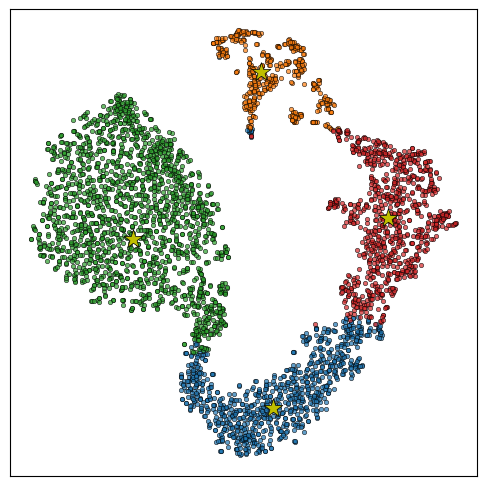

In [41]:
plot_tsne()
# plt.savefig('./figure/paper/Fig4_4b', dpi=300)

### Plot matrices during training

(-0.3, 5.0)

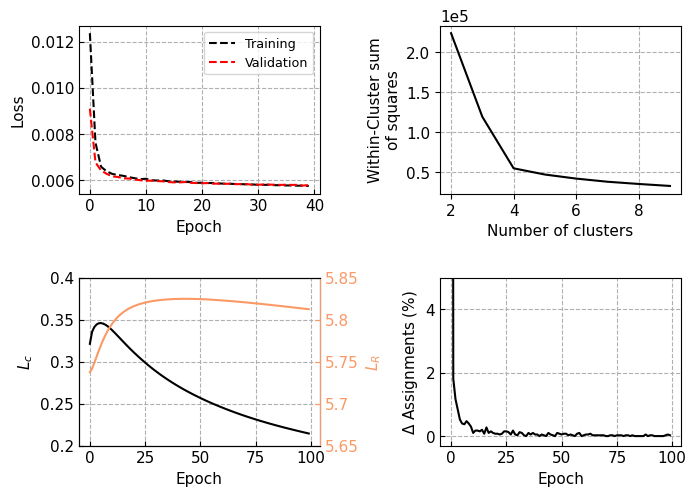

In [42]:
tol = []
labels_prev0 = np.zeros(log_label.shape[1])
for i in range(log_label.shape[0]):
    labels = log_label[i]
    tol.append(np.sum(labels != labels_prev0).astype(np.float32)/labels.shape[0])
    labels_prev0 = labels
    
fig, [[ax0, ax3], [ax1, ax2]] = plt.subplots(ncols=2, nrows=2, figsize=(7,5))
fig.subplots_adjust(left=0.1, bottom=0.1, right=0.96, top=0.94, wspace=0.5, hspace=0.5)

ax0.plot(loss1, label='Training', c='k', ls='--')
ax0.plot(loss2, label='Validation', c='r', ls='--')
ax0.set_xlabel('Epoch')
ax0.set_ylabel('Loss')
# ax.tick_params(axis='x', labelsize=11)
# ax.tick_params(axis='y', labelsize=11)
ax0.yaxis.set_major_locator(MultipleLocator(0.002))
ax0.xaxis.set_major_locator(MultipleLocator(10))
ax0.legend(fontsize='small')
ax0.grid(ls='--')
ax0.tick_params(axis='both', direction='in')

ax3.plot(K, wcss, c='k')
ax3.set_ylabel('Within-Cluster sum\nof squares')
ax3.set_xlabel('Number of clusters')
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax3.grid(ls='--')

ax1.plot(log_loss[:,1], c='k', label='loss_cluster')
ax1.set_ylim([0.2,0.4])
ax1.yaxis.set(ticks=[0.2, 0.25, 0.3, 0.35, 0.4],ticklabels=[0.20, 0.25, 0.30, 0.35, 0.40])
ax1.set_ylabel('$L_c$', c='k')
ax1.spines['left'].set_color('k')
ax1.tick_params(axis='y', colors='k')


ax1s = ax1.twinx()
ax1s.plot(log_loss[:,2], c='#FB9966',label='loss_reconstruction')
ax1s.set_ylim([5.65,5.85])
ax1s.yaxis.set(ticks=[5.65,5.7,5.75,5.8,5.85],ticklabels=[5.65,5.7,5.75,5.8,5.85])

ax1s.spines['right'].set_color('#FB9966')
ax1s.tick_params(axis='y', colors='#FB9966')
ax1s.set_ylabel('$L_R$', c='#FB9966')
ax1.set_xlabel('Epoch')
ax1s.tick_params(axis='both', direction='in')
ax1.tick_params(axis='both', direction='in')

ax1.grid(ls='--')

ax2.plot(np.array(tol[:])*100, c='k')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('$\Delta$ Assignments (%)')
ax2.tick_params(axis='both', direction='in')
ax2.grid(ls='--')
ax2.set_ylim([-0.3,5])

# plt.savefig('./DEC_DAS/figure/fig4.png', dpi=300)

## 3.6. Check clustering results

Plot examples from each cluster (Figure 6). 

From top to bottom: cluster 0->4 or rain-induced noise from weak to strong. 

From left to right: close -> far to the centriods. (5, 25, 50, 75 percentile)

In [14]:
# Get actual frequency labels for frequency samples
freq_stft = get_stft_freq()
# Run the clustering for the whole training dataset
centroids = DEC.clusterlayer.clustcenters.detach().cpu().numpy()
y_train, x_train, z_train = DEC(d_train)
label_train = y_train.max(1)[1].detach().cpu().numpy()
z_train = z_train.detach().cpu().numpy()

In [16]:
select_index_percentile = np.zeros([4,4], dtype=int)
for i, iclass in enumerate([1, 2, 0, 3]):
    for j, percentile in enumerate([5, 25, 50, 90]):
        class_idx = np.where(label_train==iclass)[0]
        # sort index of percentile
        dist = np.sqrt(np.mean((z_train[class_idx]-centroids[iclass])**2, axis=1))
        index_percentile = np.argsort(np.abs(dist - np.percentile(dist, percentile)))[:6]
        select_index_percentile[i, j] = int(class_idx[index_percentile[0]])

In [17]:
# Presaved index, to keep figures in the paper consistent (not affected by random state)
select_index_percentile = np.array([[1220, 2181,  3663,  462],
                                    [3970, 1321,   10, 548],
                                    [1407, 2254, 1985, 3802],
                                    [3896, 1331, 3500, 2727]])

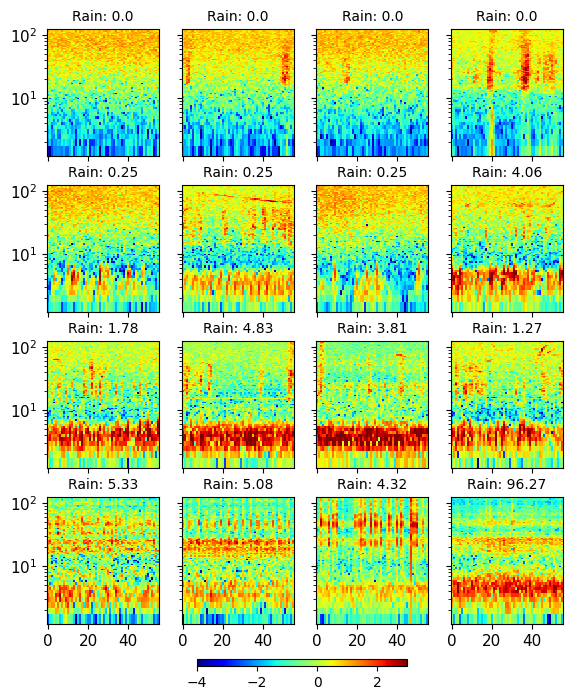

In [18]:
fig, ax = plt.subplots(nrows=args.n_clusters, ncols=len(percentile_list), figsize = (6,7))
fig.subplots_adjust(left=0.1, bottom=0.11, right=0.96, top=0.96, hspace=0.23)
for i in range(4): # reorder the class from no rain to heavy rain
    for j in range(4):
        img_index = select_index_percentile[i,j]
        img = d_train[img_index].view(76,56).cpu().detach().numpy()

        im = ax[i][j].pcolormesh(np.arange(0,56), freq_stft, img, cmap='jet', vmin=-4, vmax=3, shading='auto')
        ax[i][j].set_yscale('log')
        ax[i][j].xaxis.set_major_locator(MultipleLocator(20))
        rain_str = np.round(rain_train[index_train][img_index]*25.4, 2)
        # ax[i][j].text(35, 70, str(rain_str))
        ax[i][j].set_title(f'Rain: {str(rain_str)}', fontsize=10)
        if i < args.n_clusters-1:
            ax[i][j].set_xticklabels([])
        if j > 0:
            ax[i][j].set_yticklabels([])

cbar_ax = fig.add_axes([0.35, 0.05, 0.35, 0.01])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.tick_params(labelsize=10)

# plt.savefig('./figure/wrr/Fig6', dpi=300)

# 4. Test well-trained DEC model
```
We use the plot showing predictions from DEC with precipitation data, waveforms, and PSDs to evaluate the performace.
This code section is for the multiple rain events example on Aug 18, 2021. (Fig 10)
```

In [16]:
import obspy
from matplotlib import mlab
from scipy.signal import medfilt

## 4.1. DEC predictions

In [17]:
# load model 
DEC = DEC_net(args).cuda()
DEC.load_state_dict(torch.load(workdir+'/results/model_weights/DEC_weights', map_location=device))

<All keys matched successfully>

In [18]:
# Test use data on aug 18-19 (several rain events)
data_test = preprocess_input(data2[48*60*24:49*60*24+60*12])
d_test = torch.from_numpy(data_test).to(device).to(torch.float32)

In [19]:
# Prediction before DEC
y_pred, _, _ = DEC_init(d_test)
y = y_pred.max(1)[1].detach().cpu().numpy()
y_after_init = switch_label(y, [1,2,0,3]) # [0,2,1,3]
y_after_init = medfilt(y_after_init, kernel_size=3)

# Prediction after DEC
y_pred, _, _ = DEC(d_test)
y = y_pred.max(1)[1].detach().cpu().numpy()
y_after = switch_label(y, [1,2,0,3]) # [2,0,3,1]
y_after = medfilt(y_after, kernel_size=3)

## 4.2. Load other resources for validation

In [20]:
# load calculated PSD in every minute.  

t0 = obspy.UTCDateTime('202106010000')
start = obspy.UTCDateTime('202108180000')
end = obspy.UTCDateTime('202108191200')
psd_all = np.load(f'{workdir}/data/DAS_psd/Ch359_psd_0601_0930.npy')
psd = psd_all[int((start-t0)/60):int((end-t0)/60)]

# get frequency of PSD
Fs = 250
divs_per_window = 13 
window_len = 60 # second
nfft = int(window_len / divs_per_window * Fs)
ovlp = 0.5
spec, freq_psd = mlab.psd(np.ones(60*250), nfft, Fs, detrend=mlab.detrend_linear, window=fft_taper,
                      noverlap=int(ovlp * nfft), sides='onesided', scale_by_freq=True)

In [21]:
# load original waveforms
D359 = obspy.read('/egg1/s2/jxs2475/codes/ch359.sac')
D = D359.copy().trim(starttime=start, endtime=end+0.004)

In [22]:
# load precipitation during test period
df_sub = df[df.index.isin(pd.date_range(start='2021-08-18 00:00',
                                    end='2021-08-19 12:00',freq='T'))]
rain = df_sub['Rain Rate'].values

## 4.3. Plotting

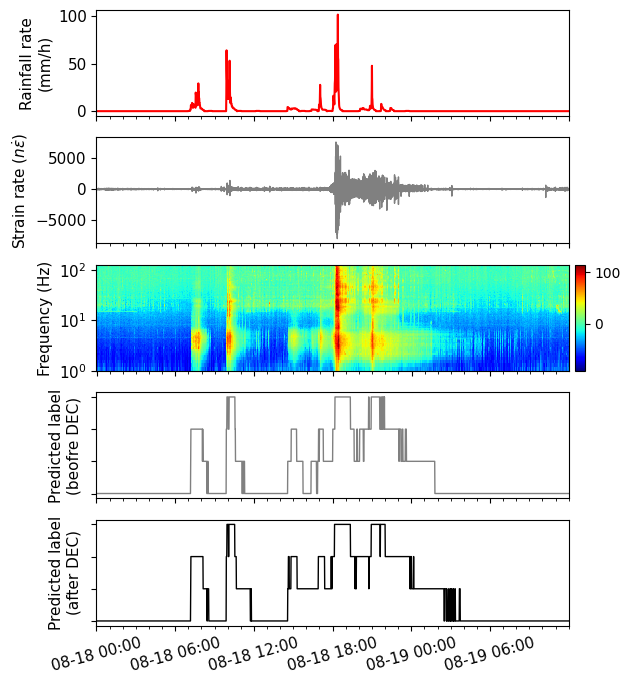

In [33]:
fig, axes = plt.subplots(ncols=1, nrows=5, figsize=(6.3,7))
fig.subplots_adjust(left=0.15, bottom=0.08, right=0.9, top=0.96, hspace=0.2)
axes[0].plot(rain*25.4, c='r')
axes[0].set_ylabel('Rainfall rate\n(mm/h)')
axes[0].set_xlim([0,rain.size])
axes[0].xaxis.set_major_locator(MultipleLocator(6*60))
axes[0].xaxis.set_minor_locator(MultipleLocator(60))
axes[0].set_xticklabels([])

axes[1].plot(D[0].data, lw=1, c='gray')
axes[1].set_ylabel('Strain rate ($n\dot{\epsilon}$)')
axes[1].xaxis.set_major_locator(MultipleLocator(6*60*60*250))
axes[1].xaxis.set_minor_locator(MultipleLocator(60*60*250))
axes[1].set_xticklabels([])
axes[1].set_xlim([0, D[0].data.size])

im = axes[2].pcolormesh(np.arange(0,psd.shape[0]), freq_psd+freq_psd[1]-freq_psd[0], 10*np.log(psd.T), 
                        cmap=plt.get_cmap('jet'), shading='auto')
axes[2].set_yscale('log')
axes[2].set_ylim([1,125])
axes[2].xaxis.set_major_locator(MultipleLocator(6*60))
axes[2].xaxis.set_minor_locator(MultipleLocator(60))
axes[2].yaxis.set_major_locator(LogLocator(base=10, numticks=30))
axes[2].yaxis.set_minor_locator(LogLocator(base=10, numticks=10))
axes[2].set_xticklabels([])
axes[2].set_ylabel('Frequency (Hz)')

label_dates = [x.strftime("%m-%d %H:%M") for x in 
               pd.date_range(start='2021-08-18 00:00',end='2021-08-19 11:00', freq='6H')]

# axes[3].plot(range(y_after.shape[0]), 10*np.log(amp), lw=1, c='k', alpha=0.9)
axes[3].plot(range(y_after.shape[0]), y_after_init, lw=1, c='gray')
axes[3].xaxis.set(ticks=np.arange(0,y_after.shape[0],6*60),ticklabels=label_dates)
axes[3].set_xlim([0,rain.size])
axes[3].tick_params(axis='x', labelrotation = 15)
axes[3].xaxis.set_minor_locator(MultipleLocator(60))
axes[3].yaxis.set_major_locator(MultipleLocator(1))
axes[3].set_xticklabels([])
axes[3].set_yticklabels([])
axes[3].set_ylabel('Predicted label\n(beofre DEC)')

axes[4].plot(range(y_after.shape[0]), y_after, lw=1, c='k')
# axes[3].plot(range(y_after.shape[0]), y_after1, lw=1, c='r', alpha=0.9)
axes[4].xaxis.set(ticks=np.arange(0,y_after.shape[0],6*60),ticklabels=label_dates)
axes[4].set_xlim([0,rain.size])
axes[4].tick_params(axis='x', labelrotation = 15)
axes[4].xaxis.set_minor_locator(MultipleLocator(60))
axes[4].yaxis.set_major_locator(MultipleLocator(1))
axes[4].set_yticklabels([])
axes[4].set_ylabel('Predicted label\n(after DEC)')

pos = axes[2].get_position()
cbar_ax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar_ax.tick_params(labelsize=10)

# axes[4].tick_params(axis='x',which='major',direction='out',length=5,width=1.4)
# plt.savefig('./DEC_DAS/figure/Fig7', dpi=300)